In [115]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


In [116]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "dermamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [117]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


(7007, 1003, 2005)

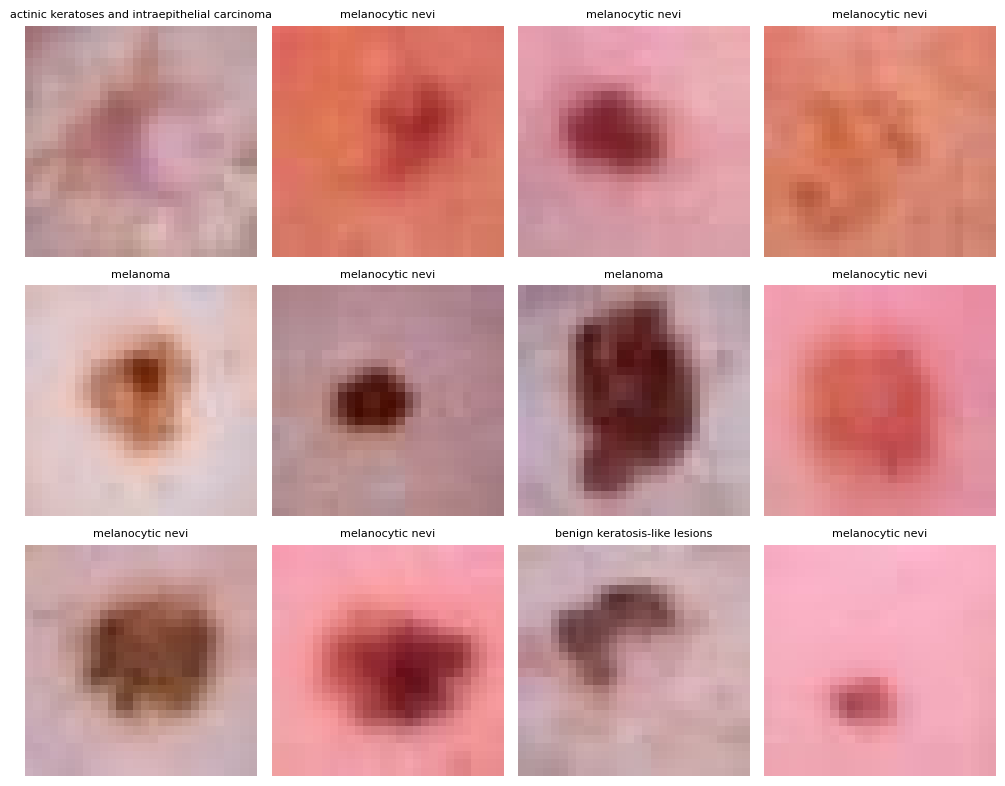

In [118]:
def show_batch(dataset, n=12):

    plt.figure(figsize=(10,8))

    for i in range(n):

        x, y = dataset[i]

        plt.subplot(3,4,i+1)

        # Cambiar de (3,28,28) a (28,28,3)
        img = x.permute(1,2,0).numpy()

        plt.imshow(img)

        label = info["label"][str(int(y.item()))]

        plt.title(label, fontsize=8)

        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_batch(train_dataset, n=12)

In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [120]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

In [121]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=7, bias=True)
  )
)

In [122]:
class CNN_Improved(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.4),

            nn.Linear(
                128,
                num_classes
            )
        )


    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [123]:
model_improved = CNN_Improved(
    num_classes=num_classes
).to(device)


model_improved

CNN_Improved(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=128, out_features=7, bias=True)
  )
)

In [124]:
criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(
    model_improved.parameters(),
    lr=1e-3
)


scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.5
)


epochs = 10


history_improved = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_auc": []
}



for epoch in range(1, epochs + 1):

    train_loss = train_one_epoch(
        model_improved,
        train_loader,
        optimizer,
        criterion
    )


    train_acc = evaluate_train(
        model_improved,
        train_loader
    )


    val_acc, val_auc, _, _, _ = evaluate(
        model_improved,
        val_loader
    )


    history_improved["train_loss"].append(train_loss)

    history_improved["train_acc"].append(train_acc)

    history_improved["val_acc"].append(val_acc)

    history_improved["val_auc"].append(val_auc)


    scheduler.step()


    print(
        f"Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | loss=1.0704 | train_acc=0.6944 | val_acc=0.7049 | val_auc=0.8728
Epoch 02 | loss=0.8236 | train_acc=0.7059 | val_acc=0.7019 | val_auc=0.8774
Epoch 03 | loss=0.8001 | train_acc=0.7083 | val_acc=0.7129 | val_auc=0.8777
Epoch 04 | loss=0.7643 | train_acc=0.7013 | val_acc=0.6949 | val_auc=0.8768
Epoch 05 | loss=0.7485 | train_acc=0.7287 | val_acc=0.7278 | val_auc=0.9122
Epoch 06 | loss=0.7374 | train_acc=0.7144 | val_acc=0.7198 | val_auc=0.9118
Epoch 07 | loss=0.7174 | train_acc=0.7397 | val_acc=0.7438 | val_auc=0.9188
Epoch 08 | loss=0.7152 | train_acc=0.7417 | val_acc=0.7498 | val_auc=0.9194
Epoch 09 | loss=0.7098 | train_acc=0.7423 | val_acc=0.7478 | val_auc=0.9187
Epoch 10 | loss=0.6945 | train_acc=0.7458 | val_acc=0.7428 | val_auc=0.9191


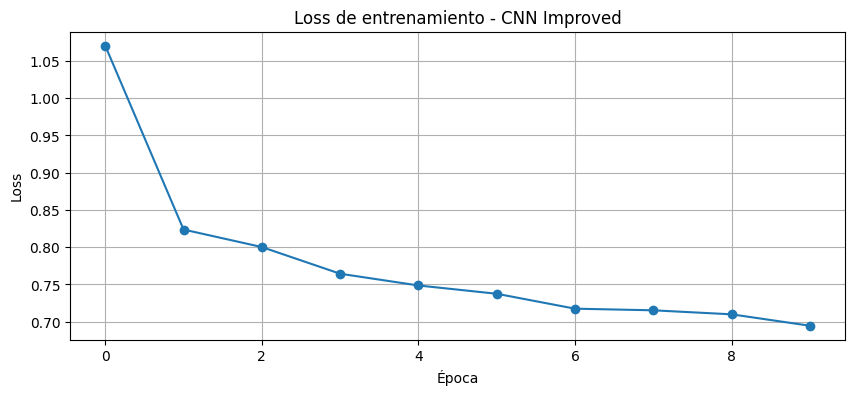

In [125]:
plt.figure(figsize=(10,4))

plt.plot(
    history_improved["train_loss"],
    marker="o"
)

plt.title(
    "Loss de entrenamiento - CNN Improved"
)

plt.xlabel("Época")

plt.ylabel("Loss")

plt.grid()

plt.show()

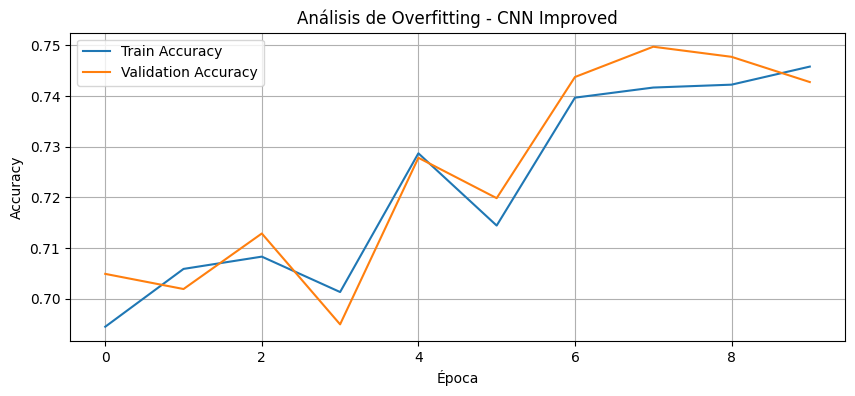

In [126]:
plt.figure(figsize=(10,4))

plt.plot(
    history_improved["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history_improved["val_acc"],
    label="Validation Accuracy"
)


plt.title(
    "Análisis de Overfitting - CNN Improved"
)

plt.xlabel("Época")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

In [127]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    return torch.softmax(logits, dim=1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = torch.argmax(probs, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr")
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


In [128]:
test_acc_improved, test_auc_improved, y_true_imp, y_pred_imp, y_prob_imp = evaluate(
    model_improved,
    test_loader
)


print(
    f"CNN Improved | Test Accuracy: {test_acc_improved:.4f}"
)

print(
    f"CNN Improved | Test ROC-AUC: {test_auc_improved:.4f}"
)


print()

print(
    classification_report(
        y_true_imp,
        y_pred_imp,
        digits=4
    )
)

CNN Improved | Test Accuracy: 0.7377
CNN Improved | Test ROC-AUC: 0.9092

              precision    recall  f1-score   support

           0     0.5161    0.2424    0.3299        66
           1     0.3919    0.5631    0.4622       103
           2     0.5349    0.3136    0.3954       220
           3     0.0000    0.0000    0.0000        23
           4     0.5714    0.2152    0.3127       223
           5     0.8011    0.9582    0.8727      1341
           6     0.3333    0.1034    0.1579        29

    accuracy                         0.7377      2005
   macro avg     0.4498    0.3423    0.3615      2005
weighted avg     0.7000    0.7377    0.6987      2005



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


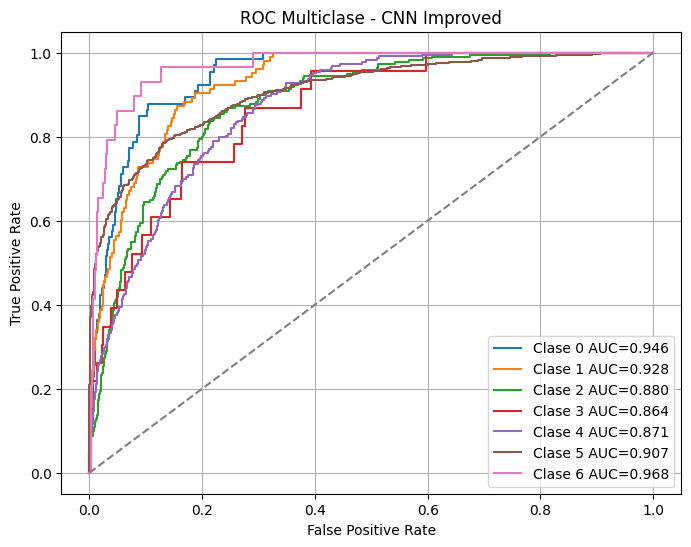

In [129]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


y_true_bin = label_binarize(
    y_true_imp,
    classes=range(num_classes)
)


plt.figure(figsize=(8,6))


for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:,i],
        y_prob_imp[:,i]
    )


    roc_auc = auc(
        fpr,
        tpr
    )


    plt.plot(
        fpr,
        tpr,
        label=f"Clase {i} AUC={roc_auc:.3f}"
    )


plt.plot([0,1],[0,1],"--")


plt.title(
    "ROC Multiclase - CNN Improved"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid()

plt.show()

In [130]:
y_true_imp
y_prob_imp

array([[2.89839343e-03, 4.47759917e-03, 1.59051828e-02, ...,
        7.98890218e-02, 8.85513902e-01, 9.15962458e-03],
       [1.03284545e-01, 4.21148717e-01, 1.10450603e-01, ...,
        3.03796269e-02, 1.88854352e-01, 7.92998299e-02],
       [2.14908943e-02, 4.87398282e-02, 5.06249607e-01, ...,
        7.81977400e-02, 3.18301052e-01, 6.00882154e-03],
       ...,
       [8.54136306e-06, 2.64159498e-05, 4.80926188e-04, ...,
        2.15907488e-03, 9.96433377e-01, 8.56972125e-04],
       [1.23503778e-05, 6.53679090e-05, 5.27383352e-04, ...,
        8.38232518e-05, 9.99177039e-01, 8.79970321e-05],
       [6.70792302e-03, 1.54419541e-01, 8.81037936e-02, ...,
        1.62870251e-02, 7.04065859e-01, 2.09018830e-02]], dtype=float32)

In [131]:
from sklearn.calibration import calibration_curve

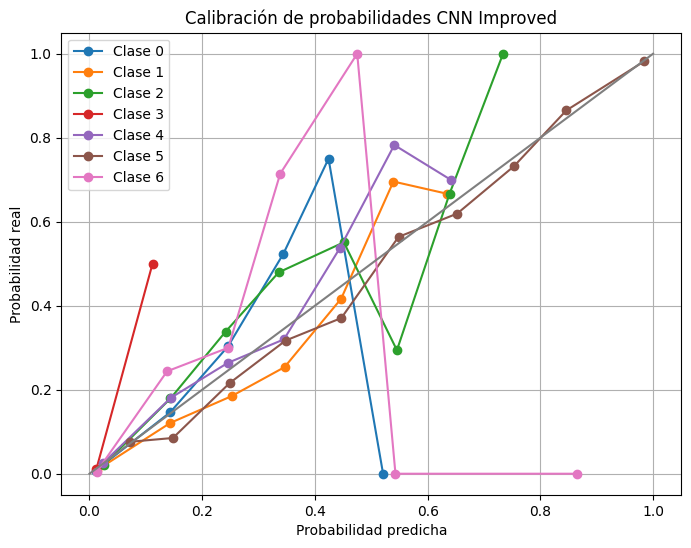

In [132]:
plt.figure(figsize=(8,6))

for i in range(num_classes):

    prob_true, prob_pred = calibration_curve(
        y_true_bin[:,i],
        y_prob_imp[:,i],
        n_bins=10
    )


    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=f"Clase {i}"
    )


plt.plot(
    [0,1],
    [0,1]
)

plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad real")

plt.title(
    "Calibración de probabilidades CNN Improved"
)

plt.legend()
plt.grid()
plt.show()

In [133]:
@torch.no_grad()
def evaluate_train(model, loader):

    model.eval()

    correct = 0
    total = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)

        preds = torch.argmax(logits, dim=1)

        correct += (preds == y).sum().item()

        total += y.size(0)

    acc = correct / total

    return acc

In [134]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3
)

epochs = 8

history_scratch = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_auc": []
}


for epoch in range(1, epochs + 1):

    # Entrenamiento
    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )


    # Métrica del entrenamiento
    train_acc = evaluate_train(
    model_scratch,
    train_loader
)


    # Validación
    val_acc, val_auc, _, _, _ = evaluate(
        model_scratch,
        val_loader
    )


    # Guardar historial
    history_scratch["train_loss"].append(train_loss)

    history_scratch["train_acc"].append(train_acc)

    history_scratch["val_acc"].append(val_acc)

    history_scratch["val_auc"].append(val_auc)


    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | train_loss=1.2584 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.5227
Epoch 02 | train_loss=1.1042 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.6723
Epoch 03 | train_loss=1.0376 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.7031
Epoch 04 | train_loss=1.0122 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.7178
Epoch 05 | train_loss=0.9993 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.7360
Epoch 06 | train_loss=0.9914 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.7476
Epoch 07 | train_loss=0.9847 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.7557
Epoch 08 | train_loss=0.9767 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.7680


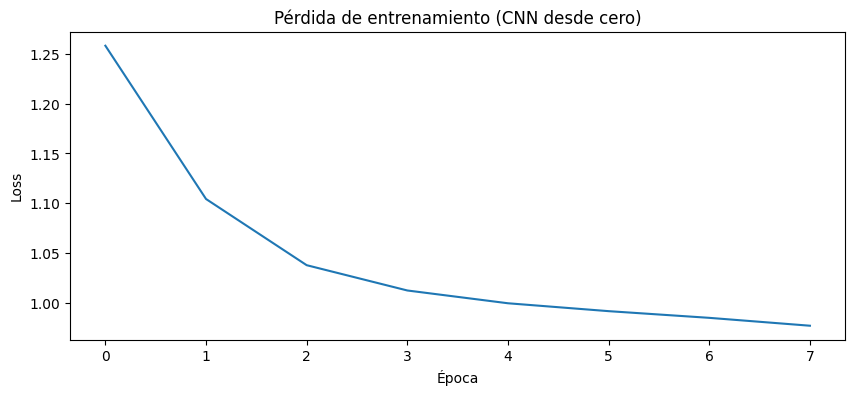

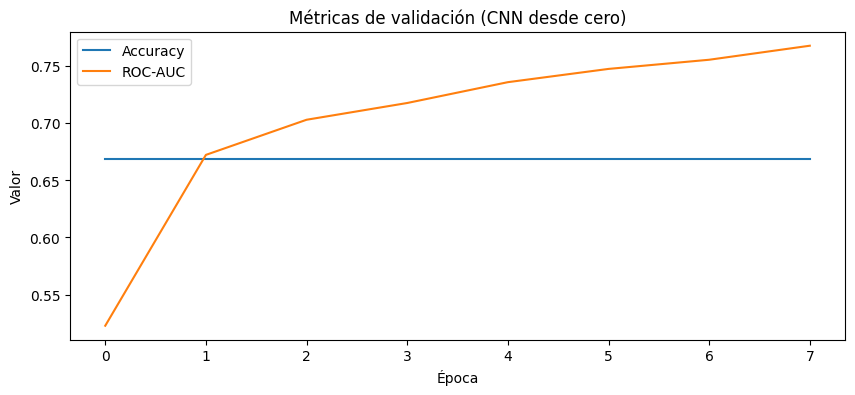

In [135]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


In [136]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.6688
Test ROC-AUC:  0.7659

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        66
           1     0.0000    0.0000    0.0000       103
           2     0.0000    0.0000    0.0000       220
           3     0.0000    0.0000    0.0000        23
           4     0.0000    0.0000    0.0000       223
           5     0.6688    1.0000    0.8016      1341
           6     0.0000    0.0000    0.0000        29

    accuracy                         0.6688      2005
   macro avg     0.0955    0.1429    0.1145      2005
weighted avg     0.4473    0.6688    0.5361      2005



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[   0,    0,    0,    0,    0,   66,    0],
       [   0,    0,    0,    0,    0,  103,    0],
       [   0,    0,    0,    0,    0,  220,    0],
       [   0,    0,    0,    0,    0,   23,    0],
       [   0,    0,    0,    0,    0,  223,    0],
       [   0,    0,    0,    0,    0, 1341,    0],
       [   0,    0,    0,    0,    0,   29,    0]])

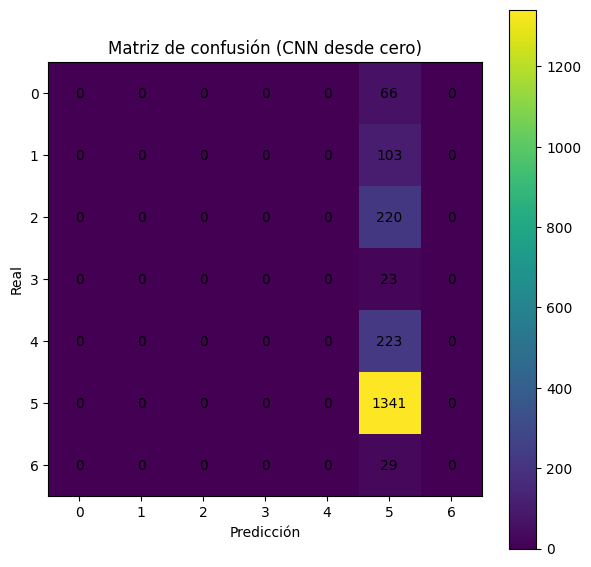

In [137]:
plt.figure(figsize=(7, 7))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks( range(num_classes),
    range(num_classes)
)
plt.yticks(range(num_classes),
    range(num_classes)
)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


In [138]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [139]:
model_aug = SimpleCNN(
    num_classes=num_classes
).to(device)


criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)


epochs = 6


history_aug = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_auc": []
}



for epoch in range(1, epochs + 1):


    # Entrenamiento usando imágenes aumentadas
    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer,
        criterion
    )


    # Accuracy del entrenamiento
    train_acc = evaluate_train(
        model_aug,
        train_loader_aug
    )


    # Validación con imágenes originales
    val_acc, val_auc, _, _, _ = evaluate(
        model_aug,
        val_loader
    )


    # Guardar historial
    history_aug["train_loss"].append(train_loss)

    history_aug["train_acc"].append(train_acc)

    history_aug["val_acc"].append(val_acc)

    history_aug["val_auc"].append(val_auc)



    print(
        f"Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01 | loss=1.2787 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.6294
Epoch 02 | loss=1.0721 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.6811
Epoch 03 | loss=1.0306 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.6959
Epoch 04 | loss=1.0103 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.7213
Epoch 05 | loss=0.9940 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.7737
Epoch 06 | loss=0.9742 | train_acc=0.6698 | val_acc=0.6690 | val_auc=0.8110


In [140]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.6688 | test_auc=0.7659
Con augmentation  | test_acc=0.6688 | test_auc=0.7968


In [141]:
import torchvision.models as models


transform_tl_train = T.Compose([
    T.Resize((224, 224)),

    T.RandomRotation(
        degrees=10
    ),

    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    T.ToTensor()
])


transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])


train_dataset_tl = DataClass(
    split="train",
    transform=transform_tl_train,
    download=True
)


val_dataset_tl = DataClass(
    split="val",
    transform=transform_tl_eval,
    download=True
)


test_dataset_tl = DataClass(
    split="test",
    transform=transform_tl_eval,
    download=True
)


train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [142]:
x, y = next(iter(train_loader_tl))

print(x.shape)

torch.Size([64, 3, 224, 224])


In [143]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [144]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=1.0302 | val_acc=0.7089 | val_auc=0.8210
Stage1 Epoch 02 | train_loss=0.8655 | val_acc=0.7099 | val_auc=0.8878
Stage1 Epoch 03 | train_loss=0.8185 | val_acc=0.7228 | val_auc=0.9034
Stage1 Epoch 04 | train_loss=0.7845 | val_acc=0.7378 | val_auc=0.9105


In [145]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [146]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.7216 | val_acc=0.7617 | val_auc=0.9312
Stage2 Epoch 02 | train_loss=0.5866 | val_acc=0.7607 | val_auc=0.9361
Stage2 Epoch 03 | train_loss=0.5045 | val_acc=0.7537 | val_auc=0.9340
Stage2 Epoch 04 | train_loss=0.4257 | val_acc=0.7697 | val_auc=0.9413


In [147]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.7581 | test_auc=0.9313

              precision    recall  f1-score   support

           0     0.3956    0.5455    0.4586        66
           1     0.4880    0.5922    0.5351       103
           2     0.4638    0.5818    0.5161       220
           3     0.4348    0.4348    0.4348        23
           4     0.6077    0.3543    0.4476       223
           5     0.8876    0.8889    0.8882      1341
           6     0.8235    0.4828    0.6087        29

    accuracy                         0.7581      2005
   macro avg     0.5858    0.5543    0.5556      2005
weighted avg     0.7671    0.7581    0.7569      2005



array([[  36,   13,    9,    0,    5,    3,    0],
       [  14,   61,   14,    2,    2,   10,    0],
       [  16,   13,  128,    1,   13,   49,    0],
       [   3,    2,    2,   10,    0,    6,    0],
       [  10,    9,   44,    2,   79,   77,    2],
       [  12,   22,   77,    8,   29, 1192,    1],
       [   0,    5,    2,    0,    2,    6,   14]])

In [148]:
print("Resumen de resultados en test")

print(
    f"CNN base              | acc={test_acc:.4f} | auc={test_auc:.4f}"
)

print(
    f"CNN + Augmentation     | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}"
)

print(
    f"CNN Improved           | acc={test_acc_improved:.4f} | auc={test_auc_improved:.4f}"
)

print(
    f"ResNet Transfer        | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}"
)

Resumen de resultados en test
CNN base              | acc=0.6688 | auc=0.7659
CNN + Augmentation     | acc=0.6688 | auc=0.7968
CNN Improved           | acc=0.7377 | auc=0.9092
ResNet Transfer        | acc=0.7581 | auc=0.9313


In [149]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


In [150]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")
torch.save(model_improved.state_dict(),"models/cnn_improved.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


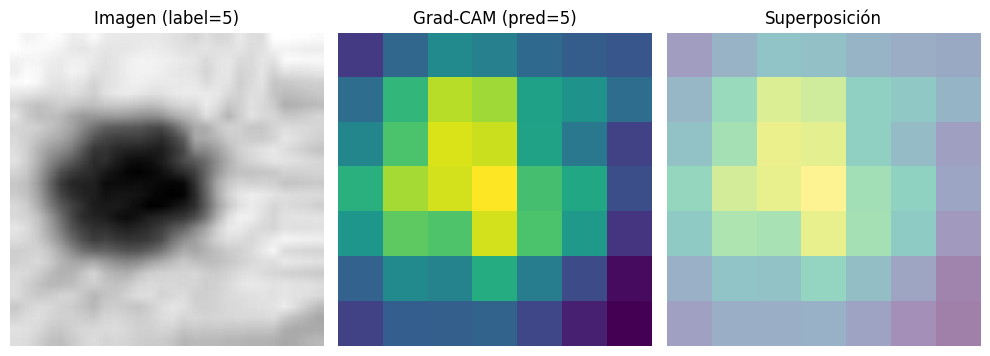

In [151]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()
